# Análise do setor de Alimentação Fora do Lar (AFL)

Este notebook analisa dados públicos de CNPJ da Receita Federal para identificar empresas ativas do setor de alimentação fora do lar. A análise será construída em etapas: importação e esquema, limpeza, filtragem por CNAE, cruzamento das tabelas, exploração dos resultados e exportação.

Nesta primeira etapa, os arquivos são lidos sem alterar os dados brutos. Todos os códigos são mantidos como texto para preservar zeros à esquerda, que são essenciais em identificadores como CNPJ, situação cadastral e CNAE.

In [1]:
from pathlib import Path

import pandas as pd

# Diretórios relativos ao projeto: os dados brutos não são alterados durante a análise.
ROOT_DIR = Path.cwd()
RAW_DIR = ROOT_DIR / "data" / "raw"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

# Layout oficial simplificado da tabela Empresas da Receita Federal.
COLUNAS_EMPRESAS = [
    "cnpj_basico",
    "razao_social",
    "natureza_juridica",
    "qualificacao_responsavel",
    "capital_social",
    "porte",
    "ente_federativo_responsavel",
]

# Layout oficial da tabela Estabelecimentos da Receita Federal.
COLUNAS_ESTABELECIMENTOS = [
    "cnpj_basico",
    "cnpj_ordem",
    "cnpj_dv",
    "identificador_matriz_filial",
    "nome_fantasia",
    "situacao_cadastral",
    "data_situacao_cadastral",
    "motivo_situacao_cadastral",
    "nome_cidade_exterior",
    "pais",
    "data_inicio_atividade",
    "cnae_fiscal_principal",
    "cnae_fiscal_secundaria",
    "tipo_logradouro",
    "logradouro",
    "numero",
    "complemento",
    "bairro",
    "cep",
    "uf",
    "municipio",
    "ddd_1",
    "telefone_1",
    "ddd_2",
    "telefone_2",
    "ddd_fax",
    "fax",
    "correio_eletronico",
    "situacao_especial",
    "data_situacao_especial",
]

# Leitura inicial de amostras: dtype=str preserva zeros à esquerda dos códigos.
# encoding='latin1' trata a codificação usada nos arquivos públicos da Receita.
empresas = pd.read_csv(
    RAW_DIR / "empresa1.csv",
    sep=";",
    encoding="latin1",
    header=None,
    names=COLUNAS_EMPRESAS,
    dtype=str,
    nrows=1000,
)

estabelecimentos = pd.read_csv(
    RAW_DIR / "estabelecimento1.csv",
    sep=";",
    encoding="latin1",
    header=None,
    names=COLUNAS_ESTABELECIMENTOS,
    dtype=str,
    nrows=1000,
)

# Não existem tabelas de domínio separadas na pasta raw; estes códigos oficiais
# permitem traduzir os campos necessários sem alterar os dados de origem.
MAPA_PORTE = {
    "00": "Não informado",
    "01": "Microempresa (ME)",
    "03": "Empresa de Pequeno Porte (EPP)",
    "05": "Demais",
}

MAPA_SITUACAO_CADASTRAL = {
    "01": "Nula",
    "02": "Ativa",
    "03": "Suspensa",
    "04": "Inapta",
    "08": "Baixada",
}

print(f"Empresas carregadas: {empresas.shape[0]:,} linhas e {empresas.shape[1]} colunas")
print(f"Estabelecimentos carregados: {estabelecimentos.shape[0]:,} linhas e {estabelecimentos.shape[1]} colunas")
display(empresas.head())
display(estabelecimentos.head())

Empresas carregadas: 1,000 linhas e 7 colunas
Estabelecimentos carregados: 1,000 linhas e 30 colunas


,cnpj_basico,razao_social,natureza_juridica,qualificacao_responsavel,capital_social,porte,ente_federativo_responsavel
0,00000000,BANCO DO BRASIL SA,2038,10,"120000000000,00",05,NaN
1,00000001,ASSOCIACAO DE AMIGOS DE BAIRRO DO CONJ PAULISTANO,3999,16,"0,00",05,NaN
2,00000002,WM&R EMPREITEIRA DE CONSTRUCAO CIVIL LIMITADA,2240,49,"0,00",05,NaN
3,00000003,CASA CARIDADE LUZETE ROBERTA DE MORAIS CONJ PA...,3999,16,"0,00",05,NaN
4,00000004,ASSOCIACAO DO PEQUENO ADOLECENTE DO CONJ PAULI...,3999,16,"0,00",05,NaN


,cnpj_basico,cnpj_ordem,cnpj_dv,identificador_matriz_filial,nome_fantasia,situacao_cadastral,data_situacao_cadastral,motivo_situacao_cadastral,nome_cidade_exterior,pais,...,municipio,ddd_1,telefone_1,ddd_2,telefone_2,ddd_fax,fax,correio_eletronico,situacao_especial,data_situacao_especial
0,07396865,0001,68,1,NaN,08,20170210,01,NaN,NaN,...,8297,47,33851125,47,33851125,47,33851125,NaN,NaN,NaN
1,64904295,0018,51,2,NaN,08,20161110,01,NaN,NaN,...,2785,11,36491000,31,33880436,82,33118379,CLAUDIO.GIGLIO@CAMIL.COM.BR,NaN,NaN
2,76016369,0003,16,2,NaN,02,20260616,00,NaN,NaN,...,7071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,52302726,0001,82,1,NaN,04,20210406,63,NaN,NaN,...,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,03618479,0001,12,1,NaN,04,20260514,63,NaN,NaN,...,7607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Etapa 2 — Construção do CNPJ completo

Cada estabelecimento é identificado por três partes: o CNPJ básico da empresa, a ordem do estabelecimento e o dígito verificador. A concatenação com largura fixa garante que os zeros à esquerda não sejam perdidos e permite análises por estabelecimento, e não apenas por empresa.

In [2]:
# Normaliza cada componente antes da concatenação para preservar a estrutura de 14 dígitos.
for coluna, largura in {
    "cnpj_basico": 8,
    "cnpj_ordem": 4,
    "cnpj_dv": 2,
}.items():
    estabelecimentos[coluna] = (
        estabelecimentos[coluna]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.zfill(largura)
    )

estabelecimentos["cnpj_completo"] = (
    estabelecimentos["cnpj_basico"]
    + estabelecimentos["cnpj_ordem"]
    + estabelecimentos["cnpj_dv"]
)

# Esta checagem confirma que o identificador final está pronto para uso no join ou exportação.
print(
    "Registros com CNPJ completo de 14 dígitos:",
    estabelecimentos["cnpj_completo"].str.len().eq(14).sum(),
    "de",
    len(estabelecimentos),
)
display(
    estabelecimentos[
        ["cnpj_basico", "cnpj_ordem", "cnpj_dv", "cnpj_completo"]
    ].head()
)

Registros com CNPJ completo de 14 dígitos: 1000 de 1000


,cnpj_basico,cnpj_ordem,cnpj_dv,cnpj_completo
0,07396865,0001,68,07396865000168
1,64904295,0018,51,64904295001851
2,76016369,0003,16,76016369000316
3,52302726,0001,82,52302726000182
4,03618479,0001,12,03618479000112


## Etapa 3 — Definição do setor AFL e seleção de empresas ativas

Para responder às perguntas de negócio, deixamos de trabalhar apenas com a amostra e carregamos todos os estabelecimentos. O recorte combina duas regras: cadastro ativo e atividade económica pertencente ao grupo AFL definido no teste.

In [2]:
# A partir daqui, usamos o arquivo completo para que as métricas representem a base inteira.
estabelecimentos = pd.read_csv(
    RAW_DIR / "estabelecimento1.csv",
    sep=";",
    encoding="latin1",
    header=None,
    names=COLUNAS_ESTABELECIMENTOS,
    dtype=str,
)

for coluna, largura in {
    "cnpj_basico": 8,
    "cnpj_ordem": 4,
    "cnpj_dv": 2,
}.items():
    estabelecimentos[coluna] = (
        estabelecimentos[coluna]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.zfill(largura)
    )

estabelecimentos["cnpj_completo"] = (
    estabelecimentos["cnpj_basico"]
    + estabelecimentos["cnpj_ordem"]
    + estabelecimentos["cnpj_dv"]
)

# Estes são os CNAEs principais definidos no escopo do teste técnico.
CNAES_AFL = {
    "4721102": "Padaria e confeitaria",
    "5611201": "Restaurantes",
    "5611203": "Lanchonetes e casas de chá",
    "5611204": "Bares sem entretenimento",
    "5611205": "Bares com entretenimento",
    "5620104": "Fornecimento de alimentos para consumo domiciliar",
}

estabelecimentos["situacao_cadastral_descricao"] = estabelecimentos[
    "situacao_cadastral"
].map(MAPA_SITUACAO_CADASTRAL).fillna("Código desconhecido")
estabelecimentos["atividade_afl"] = estabelecimentos[
    "cnae_fiscal_principal"
].map(CNAES_AFL)

estabelecimentos_afl_ativos = estabelecimentos.loc[
    (estabelecimentos["situacao_cadastral"] == "02")
    & estabelecimentos["cnae_fiscal_principal"].isin(CNAES_AFL)
].copy()

print(f"Estabelecimentos lidos: {len(estabelecimentos):,}")
print(f"Estabelecimentos AFL ativos: {len(estabelecimentos_afl_ativos):,}")
display(
    estabelecimentos_afl_ativos[
        [
            "cnpj_completo",
            "situacao_cadastral_descricao",
            "cnae_fiscal_principal",
            "atividade_afl",
        ]
    ].head()
)

Estabelecimentos lidos: 4,753,435
Estabelecimentos AFL ativos: 56,223


,cnpj_completo,situacao_cadastral_descricao,cnae_fiscal_principal,atividade_afl
60,58142886000198,Ativa,4721102,Padaria e confeitaria
255,07398182000140,Ativa,5611203,Lanchonetes e casas de chá
351,07398656000153,Ativa,5611203,Lanchonetes e casas de chá
373,06195632000134,Ativa,5611204,Bares sem entretenimento
449,00503373000185,Ativa,5611201,Restaurantes


## Etapa 4 — Cruzamento entre estabelecimentos e empresas

O estabelecimento contém a atividade e a situação cadastral; a tabela de empresas contém a razão social e o porte. O CNPJ básico é a chave comum: uma empresa pode ter vários estabelecimentos, por isso o relacionamento esperado é de muitos estabelecimentos para uma empresa.

In [3]:
empresas = pd.read_csv(
    RAW_DIR / "empresa1.csv",
    sep=";",
    encoding="latin1",
    header=None,
    names=COLUNAS_EMPRESAS,
    dtype=str,
)

# A chave precisa ter a mesma largura nos dois arquivos para o merge ser confiável.
empresas["cnpj_basico"] = (
    empresas["cnpj_basico"].fillna("").astype(str).str.strip().str.zfill(8)
)
empresas["porte_descricao"] = empresas["porte"].map(MAPA_PORTE).fillna(
    "Código desconhecido"
)

base_afl = estabelecimentos_afl_ativos.merge(
    empresas,
    on="cnpj_basico",
    how="left",
    validate="many_to_one",
    suffixes=("", "_empresa"),
)

registros_sem_empresa = base_afl["razao_social"].isna().sum()
base_afl_com_empresa = base_afl.dropna(subset=["razao_social"]).copy()
percentual_correspondencia = 100 * len(base_afl_com_empresa) / len(base_afl)

print(f"Empresas carregadas: {len(empresas):,}")
print(f"Registros AFL após o merge: {len(base_afl):,}")
print(f"Registros com correspondência em Empresas: {len(base_afl_com_empresa):,}")
print(f"Cobertura do merge: {percentual_correspondencia:.1f}%")
print(f"Registros sem correspondência: {registros_sem_empresa:,}")
display(
    base_afl[
        [
            "cnpj_completo",
            "razao_social",
            "atividade_afl",
            "porte_descricao",
        ]
    ].head()
)

Empresas carregadas: 4,494,860
Registros AFL após o merge: 56,223
Registros com correspondência em Empresas: 2,597
Cobertura do merge: 4.6%
Registros sem correspondência: 53,626


,cnpj_completo,razao_social,atividade_afl,porte_descricao
0,58142886000198,NaN,Padaria e confeitaria,NaN
1,07398182000140,NaN,Lanchonetes e casas de chá,NaN
2,07398656000153,NaN,Lanchonetes e casas de chá,NaN
3,06195632000134,NaN,Bares sem entretenimento,NaN
4,00503373000185,BAR E RESTAURANTE LACERDA LTDA,Restaurantes,Microempresa (ME)


## Etapa 5 — Análise exploratória e respostas de negócio

### 5.1 Quantas empresas AFL estão ativas?

Como um mesmo CNPJ básico pode ter vários estabelecimentos, a contagem de empresas usa CNPJ básico distinto. Na execução atual, foram identificadas **55.759 empresas AFL ativas**, responsáveis por **56.223 estabelecimentos ativos**. Essa distinção evita contar filiais como empresas diferentes.

In [5]:
import matplotlib.pyplot as plt

empresas_afl_ativas = base_afl["cnpj_basico"].nunique()
estabelecimentos_afl_ativos_count = len(base_afl)

print(f"Empresas AFL ativas: {empresas_afl_ativas:,}")
print(f"Estabelecimentos AFL ativos: {estabelecimentos_afl_ativos_count:,}")

Empresas AFL ativas: 55,759
Estabelecimentos AFL ativos: 56,223


### 5.2 Evolução das aberturas nos últimos cinco anos

A data de início da atividade representa a entrada do estabelecimento no cadastro. Como o arquivo fornecido tem uma data máxima própria, usamos os cinco anos anteriores ao último registro disponível: **18/05/2016 a 18/05/2021**.

A série mostra crescimento contínuo entre 2016 e 2020, passando de **2.106** para **8.123** aberturas. Em 2021, foram observadas **3.699** aberturas; como a janela termina em 18 de maio, esse valor representa apenas parte do ano e não deve ser comparado diretamente com anos completos.

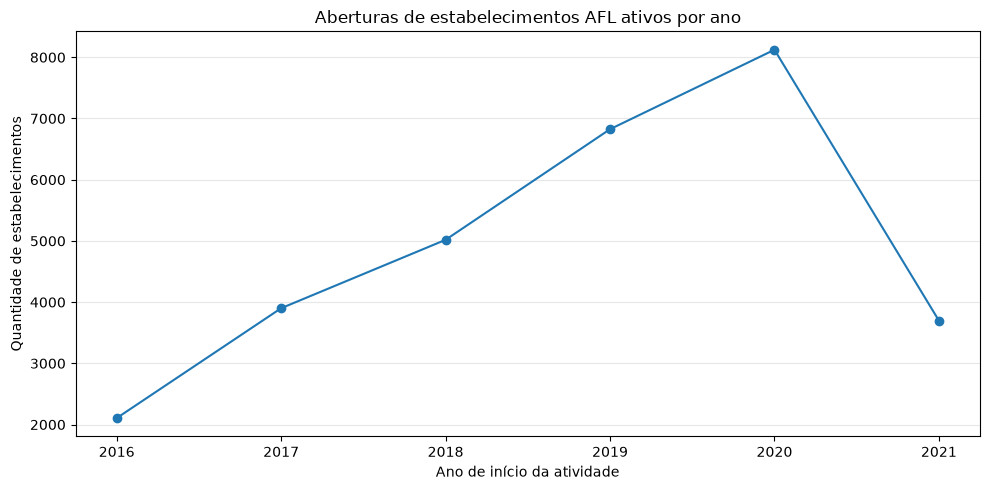

Janela analisada: 2016-05-18 a 2021-05-18


,aberturas
ano,
2016,2106
2017,3901
2018,5018
2019,6825
2020,8123
2021,3699


In [8]:
base_afl["data_inicio_atividade_dt"] = pd.to_datetime(
    base_afl["data_inicio_atividade"].astype(str).str.strip(),
    format="%Y%m%d",
    errors="coerce",
)

# A janela é ancorada no último registro disponível, e não no relógio do computador.
DATA_REFERENCIA = base_afl["data_inicio_atividade_dt"].max()
INICIO_JANELA = DATA_REFERENCIA - pd.DateOffset(years=5)

aberturas_5_anos = base_afl.loc[
    base_afl["data_inicio_atividade_dt"].between(INICIO_JANELA, DATA_REFERENCIA)
].copy()
aberturas_por_ano = (
    aberturas_5_anos.assign(ano=aberturas_5_anos["data_inicio_atividade_dt"].dt.year)
    .groupby("ano")
    .size()
    .reindex(range(INICIO_JANELA.year, DATA_REFERENCIA.year + 1), fill_value=0)
)

ax = aberturas_por_ano.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    color="#1f77b4",
    title="Aberturas de estabelecimentos AFL ativos por ano",
)
ax.set_xlabel("Ano de início da atividade")
ax.set_ylabel("Quantidade de estabelecimentos")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Janela analisada: {INICIO_JANELA.date()} a {DATA_REFERENCIA.date()}")
display(aberturas_por_ano.rename("aberturas").to_frame())

### 5.3 Qual é o porte predominante?

O porte vem da tabela Empresas, portanto esta análise usa apenas os estabelecimentos AFL ativos que tiveram correspondência no cruzamento. Na execução atual, foram encontrados **2.597 registros correspondentes**, com cobertura de **4,6%**.

Entre os registros enriquecidos, predominam as **Microempresas (ME)**, com **2.132 estabelecimentos**, seguidas pelas Empresas de Pequeno Porte (EPP), com **300**, e pelas empresas classificadas como Demais, com **165**. Os registros sem correspondência permanecem fora do gráfico e são reportados como limitação de cobertura.

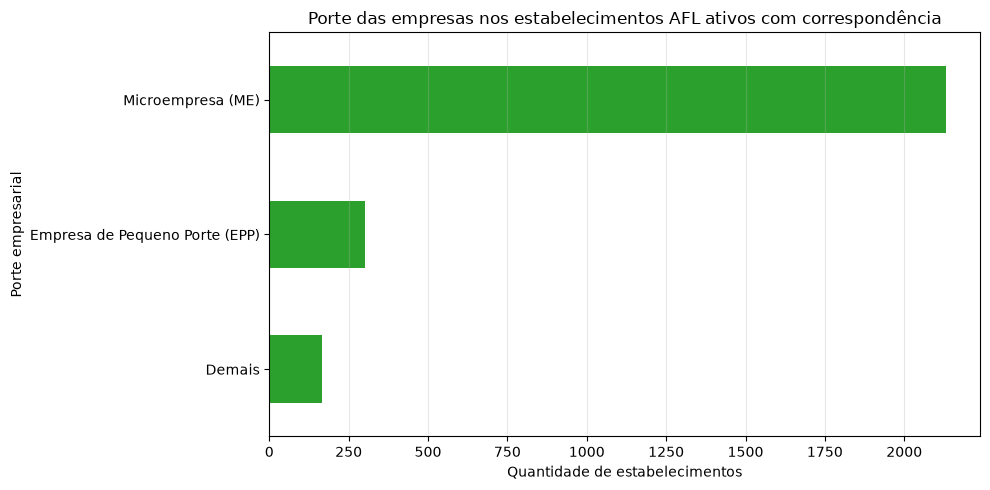

,estabelecimentos
porte_descricao,
Microempresa (ME),2132
Empresa de Pequeno Porte (EPP),300
Demais,165


In [7]:
porte_counts = base_afl_com_empresa["porte_descricao"].value_counts()

ax = porte_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#2ca02c",
    title="Porte das empresas nos estabelecimentos AFL ativos com correspondência",
)
ax.set_xlabel("Quantidade de estabelecimentos")
ax.set_ylabel("Porte empresarial")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(porte_counts.rename("estabelecimentos").to_frame())

## Etapa 6 — Exportação da base tratada

A base final será exportada para `data/processed`. Mantemos todos os estabelecimentos AFL ativos e os campos da tabela Empresas quando disponíveis; valores ausentes indicam os registros sem correspondência identificados na Etapa 4.

In [4]:
ARQUIVO_SAIDA = PROCESSED_DIR / "estabelecimentos_afl_tratados.csv"

base_afl.to_csv(
    ARQUIVO_SAIDA,
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print(f"Arquivo exportado: {ARQUIVO_SAIDA}")
print(f"Linhas exportadas: {len(base_afl):,}")
print(f"Colunas exportadas: {base_afl.shape[1]}")

Arquivo exportado: c:\Users\gustavo\teste_tecnico_abrasel\data\processed\estabelecimentos_afl_tratados.csv
Linhas exportadas: 56,223
Colunas exportadas: 40
